# EDA: `sellers`

Разведочный анализ таблицы `sellers` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM sellers"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,seller_id,seller_city,seller_state,seller_zip_code_prefix
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,13023
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,13844
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,20031
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,04195
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,12914


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_city             3095 non-null   str  
 2   seller_state            3095 non-null   str  
 3   seller_zip_code_prefix  3095 non-null   str  
dtypes: str(4)
memory usage: 96.8 KB


In [8]:
df.describe(include='all')

,seller_id,seller_city,seller_state,seller_zip_code_prefix
count,3095,3095,3095,3095
unique,3095,609,23,2246
top,3442f8959a84dea7ee197c632cb2df15,sao paulo,SP,14940
freq,1,695,1849,49


In [9]:
df.memory_usage(deep=True)

Index                        132
seller_id                 250695
seller_city               183121
seller_state              157845
seller_zip_code_prefix    167130
dtype: int64

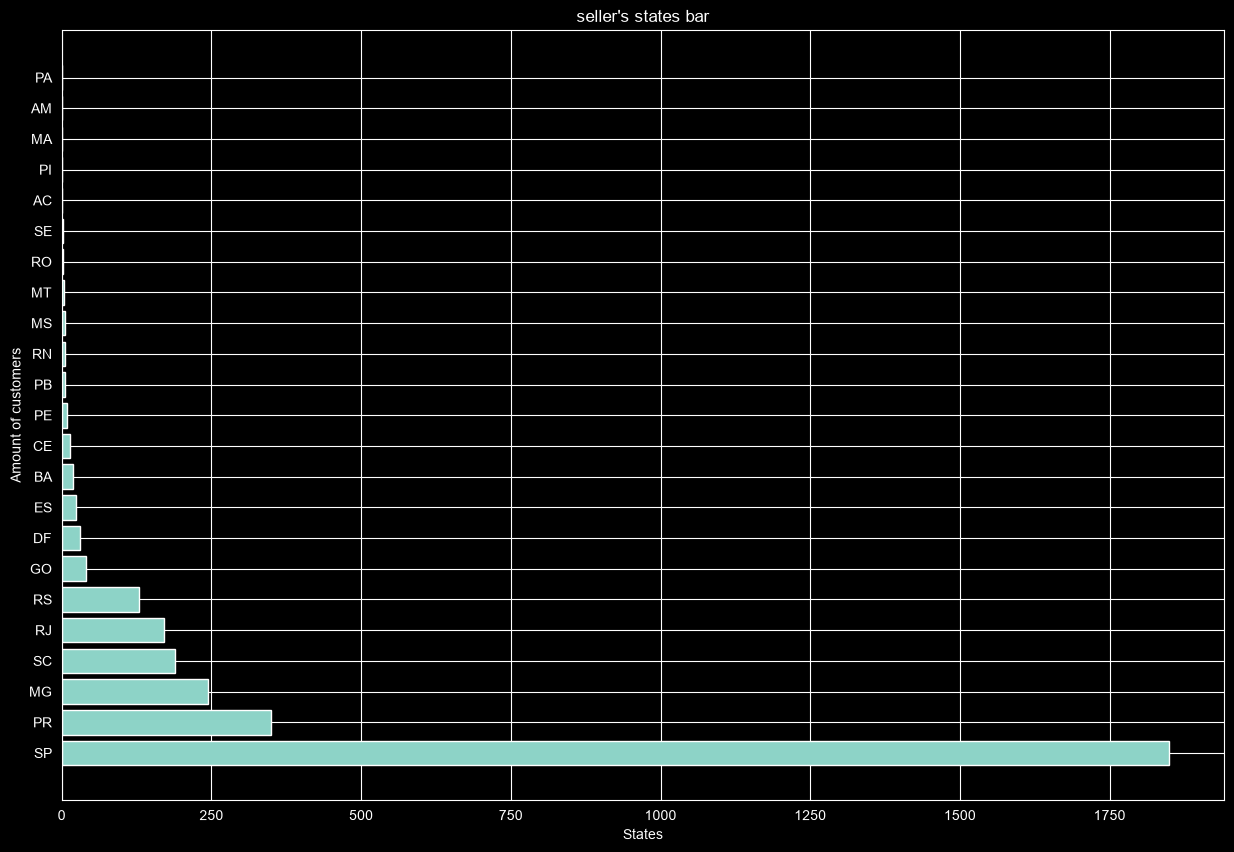

In [10]:
sampling_data = df['seller_state'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(15, 10))
plt.barh(categories, values)

plt.title("seller's states bar")
plt.xlabel('States')
plt.ylabel('Amount of customers')

plt.show()